# Basic EEG Analysis - Receptive Field function

## Imports

In [129]:
import numpy as np
import pandas as pd
import scipy as scpy
import IPython.display
from IPython.display import display, Image
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.io import loadmat
%pip install mtrf
import mtrf
from mtrf.model import TRF
import mne
import os
from os.path import join
from sklearn.model_selection import KFold
from sklearn.preprocessing import scale
from mne.decoding import ReceptiveField
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


## Loading/Resampling Data
The data used is sample data from mne's ReceptiveField tutorial. Since the mtrf dataset appeared to have been processed beforehand, preprocessing steps on a separate mne sample dataset are showcased at the end of the notebook.

In [130]:
sample_data_path = mne.datasets.mtrf.data_path()
sample_data = loadmat(join(sample_data_path, 'speech_data.mat'))
raw_eeg = sample_data['EEG'].T # Taking transpose to go from (Channels, Times) to (Times, Channels)
raw_speech = sample_data['envelope'].T # Taking transpose to go from row vector to column vector
samp_freq = float(sample_data['Fs'].item())
# Initializing Decimation factor to Downsample Speech Envelope and EEG Data
decim = 2
samp_freq /= decim
# Downsampling Speech Envelope
raw_speech = mne.filter.resample(raw_speech, down=decim, method='polyphase')
# Downsampling EEG Data
raw_eeg = mne.filter.resample(raw_eeg, down=decim, method='polyphase')

# Creating mne objects (Referenced from mne ReceptiveField tutorial)
montage = mne.channels.make_standard_montage('biosemi128')
info = mne.create_info(montage.ch_names, samp_freq, 'eeg').set_montage(montage)
raw_eeg = mne.io.RawArray(raw_eeg, info)


Polyphase resampling neighborhood: ±2 input samples
Polyphase resampling neighborhood: ±2 input samples
Creating RawArray with float64 data, n_channels=128, n_times=7677
    Range : 0 ... 7676 =      0.000 ...   119.938 secs
Ready.


## Creating/Fitting Receptive Field Encoding Model

In [131]:
# Delays used for model: Ranging from 0.1s before stimulus to 0.5s after
tmin, tmax = -0.1, 0.5
num_channels = len(raw_eeg.ch_names)
raw_speech = raw_speech.T
# Finding Ideal Ridge Regression Lambda Value
num_splits = 3 # Number of splits for cross-validation, taken from mne tutorial
lambdas = np.logspace(-3, 5, 20)
lam_avg_scores = []
# Making speech and eeg matrices the right shape
outputs, timestamps = raw_eeg[:] # Selecting only voltages from EEG data, assigning timestamps to separate varaible
outputs = outputs.T


    
        

### Sweeping across Ridge Parameter Values

In [132]:
# Sweeping across range of ridge parameters
for lam in lambdas:
    em = ReceptiveField(tmin, tmax, samp_freq, feature_names=['envelope'], estimator=lam, scoring='corrcoef')
    r_scores = np.zeros((num_splits, num_channels))
    cv = KFold(num_splits)
    # Performing cross-validation and scoring receptive_field model for each lambda value
    for i, (train, test) in enumerate(cv.split(raw_speech)):
        em.fit(raw_speech[train], outputs[train])
        r_scores[i] = em.score(raw_speech[test], outputs[test])
    lam_avg_scores.append(np.mean(r_scores))

Fitting 1 epochs, 1 channels


  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

Fitting 1 epochs, 1 channels


  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

Fitting 1 epochs, 1 channels


...

  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

Fitting 1 epochs, 1 channels


  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

Fitting 1 epochs, 1 channels


  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

### Plot of Ridge Parameter Sweep

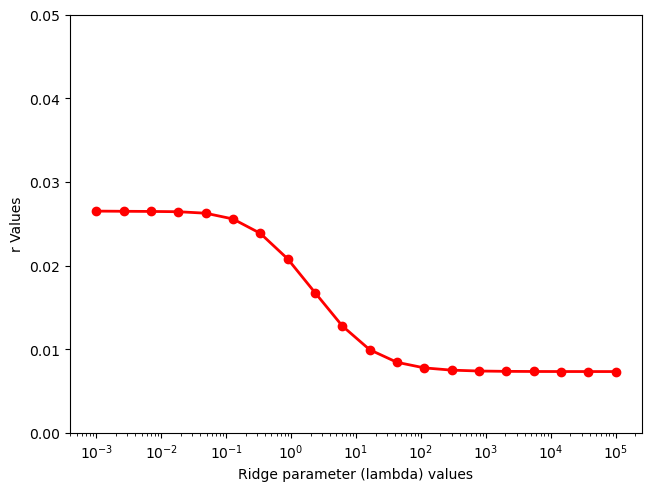

In [133]:
# Plotting Ridge parameter sweep
fig, axis = plt.subplots(layout='constrained')

axis.plot(lambdas, lam_avg_scores, marker='o', linestyle='-', color='r', lw=2)

axis.set_ylim(0, 0.05) # Limiting range of displayed R2 values after examining raw scatterplot 
axis.set_xscale('log')
plt.xlabel('Ridge parameter (lambda) values')
plt.ylabel('r Values')
plt.show()

We can start by finding the ridge parameter that maximizes our correlation coefficient.

In [134]:
# Finding lambda value with highest r value
lam = lambdas[np.argmax(lam_avg_scores)]


To avoid overfitting, we can select the largest lambda value whose correlation coefficient is within 1 standard error of the largest correlation coefficient, at $$ \lambda_{max} = 10^{-3} $$

In [135]:
max_r = max(lam_avg_scores)
r_error = np.std(lam_avg_scores)
valid_indices = np.where(lam_avg_scores >= max_r - r_error)
lam = lambdas[np.max(valid_indices)]

## Plotting TRF for 1 channel

We'll first find the EEG channel with the highest correlation coefficient with the model and then plot the TRF for that channel

### Finding channel with highest r-value

In [136]:
em = ReceptiveField(tmin, tmax, samp_freq, feature_names=['envelope'], estimator=lam, scoring='corrcoef')
# Defining tensor to hold all weights across all channels, splits, and delays
num_delays = int((tmax - tmin) * samp_freq) + 1
weights = np.zeros((num_splits, num_channels, num_delays))
# Creating matrix to store correlation coefficients
ch_scores = np.zeros((num_splits, num_channels))
for j, (train, test) in enumerate(cv.split(raw_speech)):
    em.fit(raw_speech[train], outputs[train])
    ch_scores[j] = em.score(raw_speech[test], outputs[test])
    weights[j] = em.coef_[:, 0, :] # Referenced from mne ReceptiveField tutorial--Reduce coef_ to 2 dimensions since there is only 1 feature
times = em.delays_ / float(em.sfreq)
# Finding channel with highest correlation coefficient
mean_ch_scores = ch_scores.mean(axis=0) # Averaging across splits(referenced from mne tutorial)
channel = np.argmax(mean_ch_scores)

Fitting 1 epochs, 1 channels


  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

Fitting 1 epochs, 1 channels


  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

Fitting 1 epochs, 1 channels


  0%|          | Sample : 0/2 [00:00<?,       ?it/s]

The channel with the highest correlation coefficient is channel $$ c_{max} = 117 $$ with a correlation coefficient of $$ r_{max} \approx 0.11 $$ which aligns with the values from the mne tutorial's plot.

### Plotting TRF for channel 117

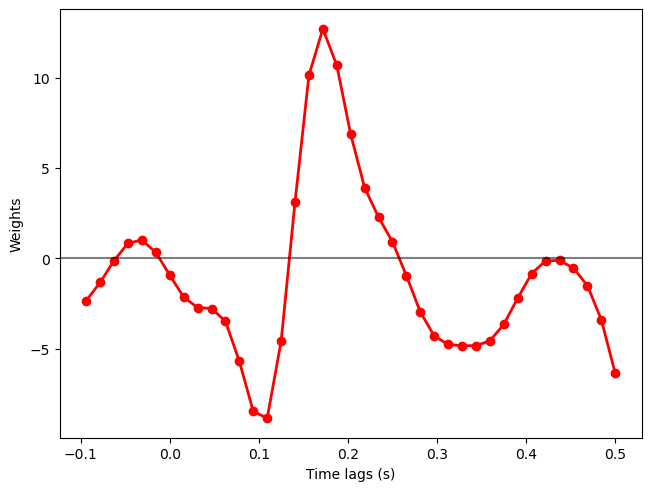

In [137]:
mean_weights = weights.mean(axis=0) # Averaging weights across splits--Referenced from mne tutorial
weights_trf = mean_weights[117]
fig_trf, axis_trf = plt.subplots(layout='constrained')

axis_trf.plot(times, weights_trf , marker='o', linestyle='-', color='r', lw=2)
plt.xlabel('Time lags (s)')
plt.ylabel('Weights')
axis_trf.axhline(0, color='k', linestyle='-', alpha=0.5)
plt.show()

Because we are using an encoding model, the TRF weights here are readily interpretable. We see that, for this channel, the speech stimulus has the largest effect on the EEG reading for a delay of approximately 200ms.

### Identifying Physical Location of Channel 117
We can highlight the physical location of EEG Channel 117 using the montage created earlier

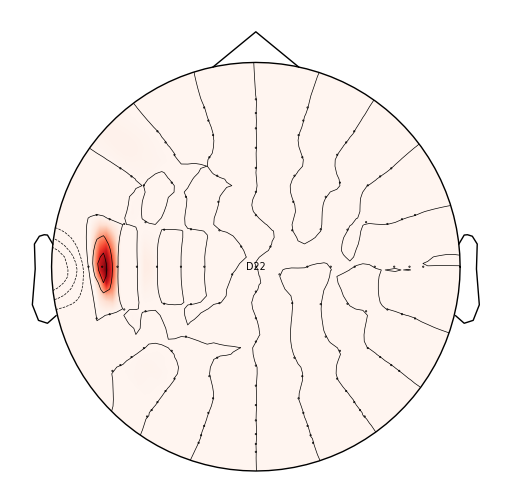

(<matplotlib.image.AxesImage at 0x20a96e9bb10>,
 <matplotlib.contour.QuadContourSet at 0x20a96e9bc50>)

In [138]:

# Getting string label for channel 117
ch_name_117 = raw_eeg.ch_names[117]
# Zeroing out all channels except 117 to highlight it on plot
data = np.zeros(len(raw_eeg.ch_names))
data[117] = 1.0
# Plotting all sensors for background of plot
mne.viz.plot_topomap(data, raw_eeg.info, size=5.0, sensors=True, names=[ch_name_117] )


We see that this channel is located in the left temporal lobe near the ear, which makes sense, as this region processes auditory information.

## Reconstructing Channel 117

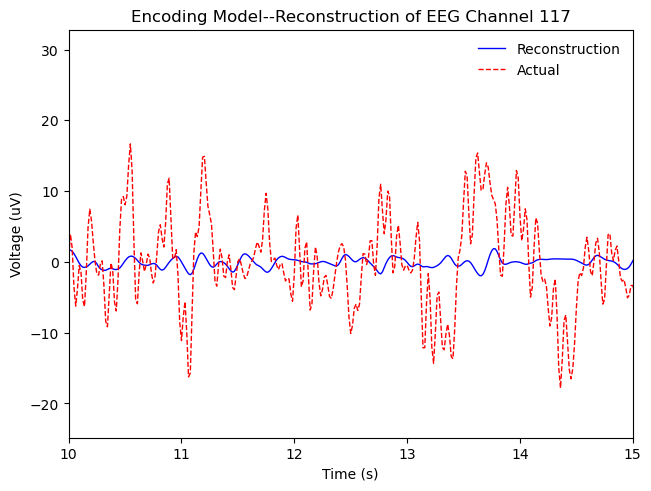

In [139]:
all_channels_pred = em.predict(raw_speech[test])
eeg_117_pred = all_channels_pred[:, 117]
timeline = np.arange(len(eeg_117_pred)) / em.sfreq
fig_recon, ax_recon = plt.subplots(layout='constrained')
ax_recon.plot(timeline, eeg_117_pred, linestyle='-', color='b', lw=1, label='Reconstruction')
ax_recon.plot(timeline, outputs[test, 117], linestyle='--', color='r', lw=1, label='Actual')
ax_recon.set_xlim(10.0, 15.0)
plt.title('Encoding Model--Reconstruction of EEG Channel 117')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (uV)')
ax_recon.legend(frameon=False, loc='upper right')
plt.show()

# Preprocessing (separate dataset)
We can use Independent Component Analysis to identify and exclude EEG components that appear to consist largely of noise from eye movements/blinks.

## Importing Data

In [140]:
sample_data = mne.datasets.sample.data_path()
sample_data_raw_file = (sample_data / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif")
raw_data = mne.io.read_raw_fif(sample_data_raw_file)

Opening raw data file C:\Users\samve\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


## Examining ICA Components
Before doing Independent Component Analysis, we applied a bandpass filter to the EEG data to remove high-frequency noise and low-frequency drifting effects due to sweating, gradual electrode movement, etc.

Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 497 samples (3.310 s)

Fitting ICA to data using 364 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 2.0s.


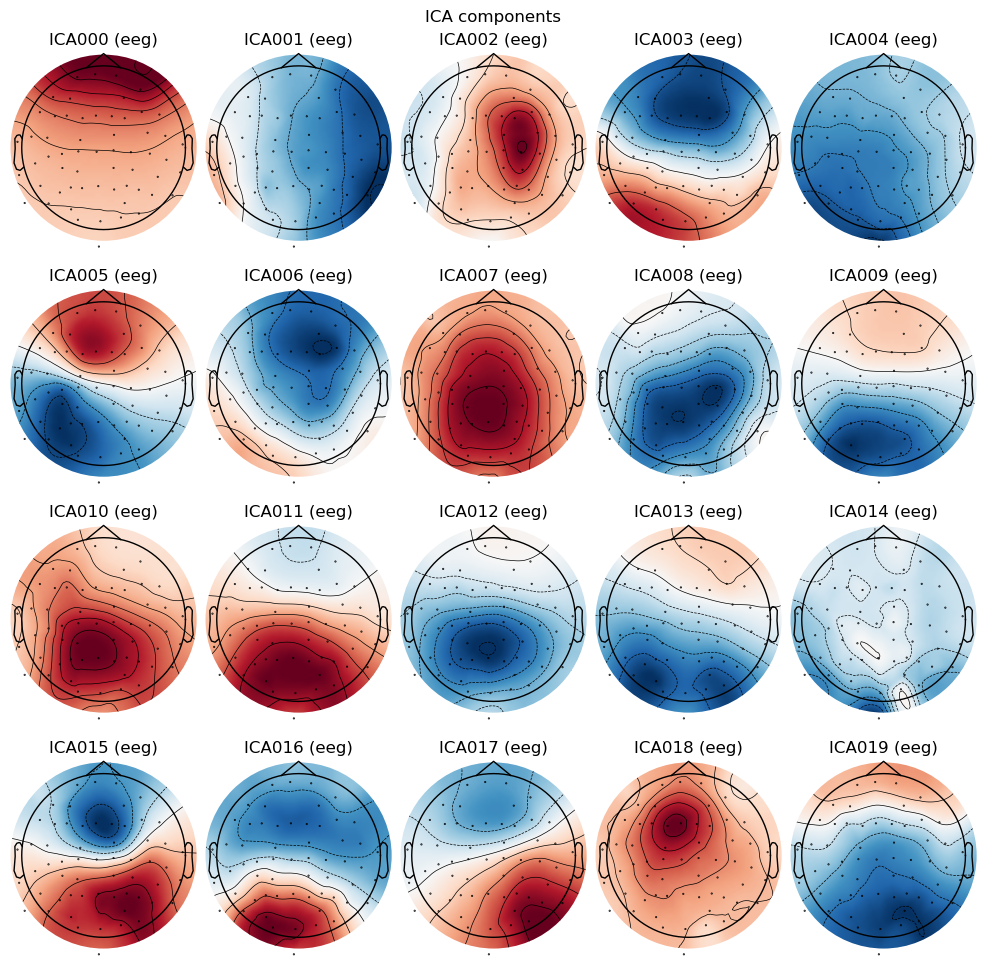

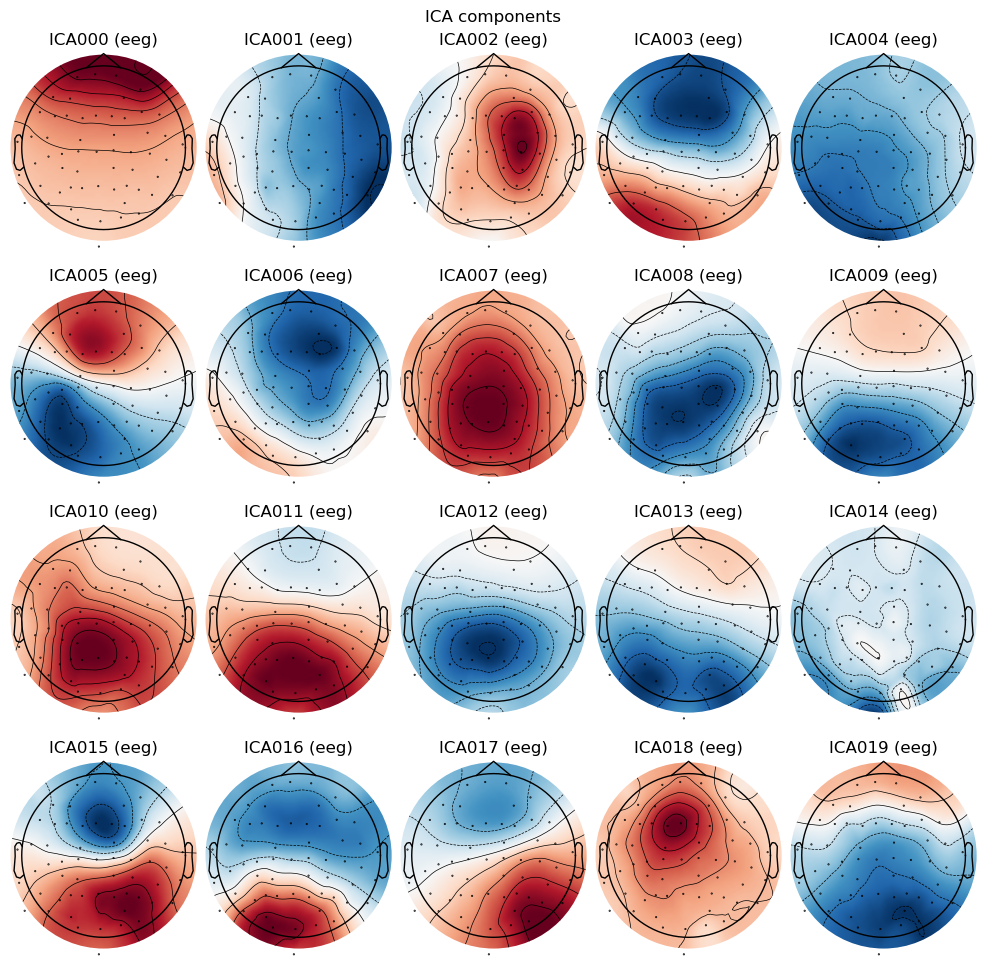

In [141]:
unprocessed_raw = raw_data.copy()
raw_data.load_data()
raw_data.filter(l_freq=1.0, h_freq=15.0)
ica = mne.preprocessing.ICA(n_components=20, random_state=0)
ica.fit(raw_data)
ica.plot_components(inst=raw_data, ch_type='eeg')

Based on scalp topography, ICA000 appears to consist of noise from blinking, as we see a concentrated voltage spike local to and symmetric around the eye area. We can examine its time series for further information.

In [142]:
ica.plot_sources(inst=raw_data)

Creating RawArray with float64 data, n_channels=21, n_times=41700
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x20aa6999b40) at 0x0000020AA8E6A340>

The time series for ICA000 displays numerous irregular spikes of large amplitude relative to other ICA components, affirming that this component likely contains noise from blinking and justifying its exclusion from the data.

In [143]:
ica.exclude = [0]
ica.apply(raw_data)

Applying ICA to Raw instance
    Transforming to ICA space (20 components)
    Zeroing out 1 ICA component
    Projecting back using 364 PCA components


<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~122.8 MiB, data loaded>